# Installing needed packages for 2m_miso

In [1]:
import torch
import random
import pandas as pd
import numpy as np
import scanpy as sc
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import logging 
import warnings
from miso.utils import *
from miso import Miso
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif
from scipy.spatial import distance_matrix
from scipy.spatial.distance import pdist, squareform
import scipy.sparse as sp
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    silhouette_score,
    accuracy_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
Image.MAX_IMAGE_PIXELS = None
Image.MAX_IMAGE_PIXELS = None

warnings.filterwarnings("ignore")

## Set up main run method (cpu/gpu)

**Parameters:** <br>
random.seed(seed=None) - Reseed the singleton RandomState instance. <br>
torch.manual_seed(seed) - Sets the seed for generating random numbers on all devices. Returns a torch.Generator object. <br>
random.seed(a=None, version=2) - Initialise the random number generator. <br>

torch.cuda.manual_seed(seed) - Set the seed for generating random numbers for the current GPU. <br>
torch.cuda.get_device_name(device=None) - Get the name of a device. <br>

In [2]:
seed=100
np.random.seed(seed)
torch.manual_seed(seed)
random.seed(seed)

if torch.cuda.is_available():
    device = 'cuda'
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print("CUDA is available. GPU:", torch.cuda.get_device_name(0))
else:
    device = 'cpu'
    print("CUDA is not available. Using CPU.")

CUDA is not available. Using CPU.


## Reading joint Spatialmeta data (Y7_T_joint)

**Parameters:** <br>
scanpy.read_h5ad(filename) - Read .h5ad-formatted hdf5 file.

In [3]:
os.chdir('miso_tutorial_data')

joint_adata_pp = sc.read_h5ad("../SpatialMETA/data/Y7_T_joint.h5ad")

joint_adata_pp.layers["counts"] = joint_adata_pp.X.copy()

print(joint_adata_pp)
print(joint_adata_pp.uns["spatial"].keys())

lib = list(joint_adata_pp.uns["spatial"].keys())[0]
print(joint_adata_pp.uns["spatial"][lib].keys())

print(joint_adata_pp.uns["spatial"][lib]["images"].keys())

AnnData object with n_obs × n_vars = 1914 × 37703
    obs: 'x_coord', 'y_coord', 'spot_name', 'total_intensity', 'mean_intensity', 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'n_genes'
    var: 'name', 'type'
    uns: 'spatial'
    obsm: 'spatial'
    layers: 'counts'
dict_keys(['Y7_T'])
dict_keys(['images', 'metadata', 'scalefactors'])
dict_keys(['hires', 'lowres'])


## Load data and perform necessary preprocessing
Preprocessing provided by MISO. The only requirement is that the dataset be split into each modality. 

**Parameters:** <br>
preprocess(adata, modality) - Takes in a specific dataset and modality type, then preprocesses and returns the usable dataset. 

In [4]:
rna = joint_adata_pp[:, joint_adata_pp.var["type"] == "ST"]
rna = preprocess(rna,modality='rna')
print(rna.shape)

protein = joint_adata_pp[:, joint_adata_pp.var["type"] == "SM"]
protein = preprocess(protein,modality='protein')
print(protein.shape)

(1914, 16615)
(1914, 1299)


## Running, training and saving the results of the MISO model 
If using a subset of modality-specific terms, the "ind_views" parameter should be a list with values that are entries to the indices of the modalities to be included, e.g.,  ind_views=[0,2] if including RNA and image features. <br>
If using a subset of interaction terms, the "combs" parameter should be a list of tuples with entries to the indices of the modalities for each interaction, e.g. combs = [(0,1),(0,2)] if including the RNA-protein and RNA-image interaction terms. <br>

**Parameters:** <br>
Miso(features, ind_views='all', combs='all', sparse=False, neighbors = None, device='cpu') - This is the step for preparing the multiple feature matrices for a learning model (model.train())<br><br>
model.train(self) - This step creates one neural network per modality (RNA, protein). Then learns the interactions between the features in both neural networks and condenses the final results into a single embedding matrix. <br><br>
np.save(file, arr, allow_pickle=True) - Save an array to a binary file in NumPy .npy format.

In [5]:
model = Miso(
    [rna,protein],
    ind_views='all',
    combs='all',
    sparse=False,
    device=device)

model.train()

np.save('emb.npy', model.emb)

Training network for modality 1:   0%|          | 0/1000 [00:00<?, ?it/s]

Training network for modality 2:   0%|          | 0/1000 [00:00<?, ?it/s]

## Set up for the clustering on the histology image
This step first reads and stores the hires image from the joint dataset. Then the scaling factors of the correct image are read and stored. After that the coordinates of the spots are scaled to the image size for correct placement. The final step is storing all the spot data into a locs (location) pandas dataframe. <br>

**Parameters:** <br>
pd.DataFrame(data=None, index=None, columns=None, dtype=None, copy=None) - Two-dimensional, size-mutable, potentially heterogeneous tabular data.

In [6]:
im = joint_adata_pp.uns["spatial"][lib]["images"]["hires"]

scale = (
    joint_adata_pp.uns["spatial"][lib]
    ["scalefactors"]["tissue_hires_scalef"]
)

coords = joint_adata_pp.obsm["spatial"] * scale

locs = pd.DataFrame(
    {
        "1": 1,                    # all spots in tissue
        "2": np.arange(len(coords)),
        "3": np.arange(len(coords)),
        "4": coords[:,1],          # row coordinate
        "5": coords[:,0],          # column coordinate
    },
    index=joint_adata_pp.obs_names
)

## Final histology image with clustering results
First the clusters are calculated by k-means. Then the clusters, spot coordinates, histology image, scale and size of dots (spots) are given to plot_on_histology. This method is from MISO and uses matplotlib to create the final image. <br>

**Parameters:**<br>
model.cluster(n_clusters) - Takes in a set amount of clusters. The method used is K-means clustering. This method returns the designated clusters in an array. <br><br>
plot_on_histology(clusters, locs, im, scale, s=10) - Takes in an array of clusters, the coordinates of spots, the histology image, the set scale and the size of the dots (spots). This method returns a histology image with clustered spots laid on top. 


In [7]:
def plot_on_histology_with_legend(clusters, locs, im, scale, s=10):
    locs = locs.copy()
    locs[['4', '5']] = locs[['4', '5']].round().astype(int)

    im_crop = im[
        (locs['4'].min()-10):(locs['4'].max()+10),
        (locs['5'].min()-10):(locs['5'].max()+10)
    ]
    
    locs[['4', '5']] = locs[['4', '5']] - locs[['4', '5']].min() + 10

    cluster_cat = pd.Categorical(clusters)
    cluster_codes = cluster_cat.codes
    cluster_names = cluster_cat.categories

    cmap1 = mcolors.ListedColormap(
        [cmap_tab70(np.array(i)) for i in range(len(cluster_names))]
    )

    plt.imshow(im_crop, alpha=0.7)
    plt.scatter(x=locs['5'], y=locs['4'], c=cluster_codes, cmap=cmap1, s=s)
    plt.axis('off')

    handles = [
        mpatches.Patch(color=cmap1(i), label=str(cluster_names[i]))
        for i in range(len(cluster_names))
    ]
    plt.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left')

Cluster 0: 191
Cluster 1: 646
Cluster 2: 580
Cluster 3: 6
Cluster 4: 1
Cluster 5: 1
Cluster 6: 211
Cluster 7: 1
Cluster 8: 48
Cluster 9: 1
Cluster 10: 1
Cluster 11: 1
Cluster 12: 178
Cluster 13: 9
Cluster 14: 39


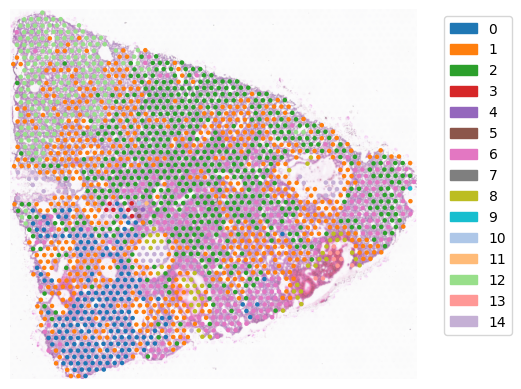

In [8]:
clusters = model.cluster(n_clusters=15)
unique, counts = np.unique(clusters, return_counts=True)
for c, n in zip(unique, counts):
    print(f"Cluster {c}: {n}")

plot_on_histology_with_legend(clusters, locs, im, scale=1.0, s=5)
plt.show()

## Benchmarking metrics

### Setup

In [9]:
joint_adata_pp.obsm["X_emb"] = model.emb
joint_adata_pp.obs["clusters"] = clusters.astype(str)

Add ground truth label to data

In [10]:
gt_adata = sc.read_h5ad("../data/06_spatialmeta_groundtruth/adata_joint_Y7_T_hvf2800.h5ad")

# Build mapping on array_row + array_col instead
gt_annotation = gt_adata.obs[['array_row', 'array_col', 'pathological_annotation']].copy()
gt_annotation['grid_key'] = (gt_annotation['array_row'].astype(str) + '_' + 
                              gt_annotation['array_col'].astype(str))
gt_annotation = gt_annotation.set_index('grid_key')

# Same key on your data
joint_adata_pp.obs['grid_key'] = (joint_adata_pp.obs['array_row'].astype(str) + '_' + 
                                joint_adata_pp.obs['array_col'].astype(str))

# Transfer annotation
joint_adata_pp.obs['pathological_annotation'] = (
    joint_adata_pp.obs['grid_key']
               .map(gt_annotation['pathological_annotation'])
)
joint_adata_pp.obs['pathological_annotation'] = (
    joint_adata_pp.obs['pathological_annotation'].astype('category')
)

# Clean up the helper column
joint_adata_pp.obs.drop(columns=['grid_key'], inplace=True)

print(joint_adata_pp.obs['pathological_annotation'].isna().sum(), "spots without annotation")
print(joint_adata_pp.obs['pathological_annotation'].value_counts())

13 spots without annotation
0     276
1     211
12    196
5     188
11    160
2     159
3     121
4     111
7     110
14    107
13     85
8      50
10     49
9      48
6      30
Name: pathological_annotation, dtype: int64


Missing spots in ground truth

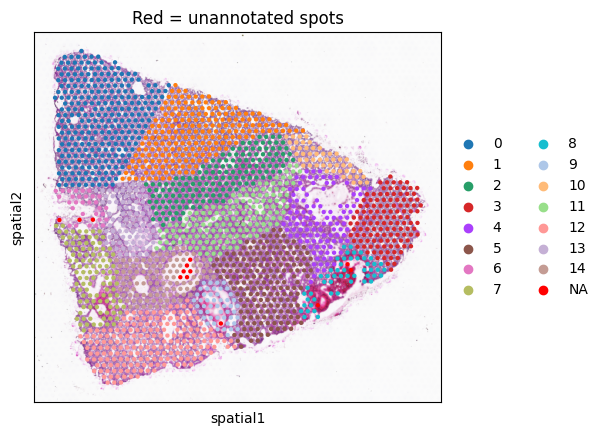

In [11]:
missing_mask = joint_adata_pp.obs['pathological_annotation'].isna()

# Plot their spatial location
sc.pl.spatial(joint_adata_pp, color='pathological_annotation', 
              na_color='red', title='Red = unannotated spots')

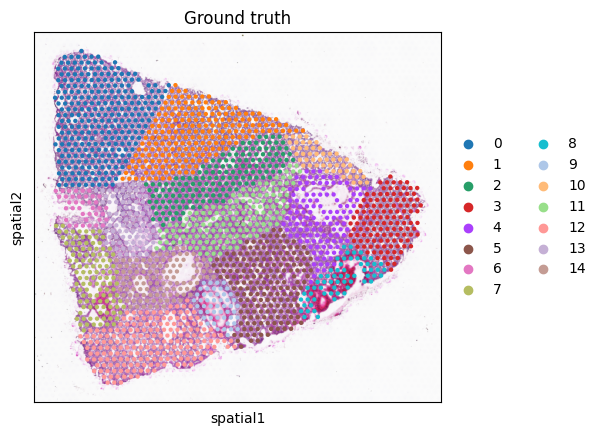

In [12]:
sc.pl.spatial(gt_adata, color='pathological_annotation', 
              na_color='red', title='Ground truth')

In [13]:
missing_mask = joint_adata_pp.obs['pathological_annotation'].isna()
joint_adata_annotated = joint_adata_pp[~missing_mask].copy()

# Remove NaN from the category levels themselves (categorical dtype retains them)
joint_adata_annotated.obs['pathological_annotation'] = (
    joint_adata_annotated.obs['pathological_annotation']
                         .cat.remove_unused_categories()
)

print(f"Spots for GT metrics: {joint_adata_annotated.n_obs}")
print(joint_adata_annotated.obs['pathological_annotation'].value_counts())

Spots for GT metrics: 1901
0     276
1     211
12    196
5     188
11    160
2     159
3     121
4     111
7     110
14    107
13     85
8      50
10     49
9      48
6      30
Name: pathological_annotation, dtype: int64


### Continuity score - Same as original

These metrics assess the smoothness and consistency of the data embedding. 

CHAOS — measures spatial compactness of clusters by averaging nearest-neighbor distances within each cluster. Lower is more compact/smooth.

PAS (Proportion of Ambiguous Spots) — for each spot, checks whether the majority of its 10 nearest spatial neighbors belong to a different cluster. Returns the fraction of such "ambiguous" spots. Lower is more spatially consistent.

In [14]:
def fx_1NN(i, location_in):
    """Calculate the distance to the nearest neighbor for a point"""
    location_in = np.array(location_in)
    dist_array = distance_matrix(location_in[i,:][None,:], location_in)[0,:]
    dist_array[i] = np.inf
    return np.min(dist_array)

def fx_kNN(i, location_in, k, cluster_in):
    """Check if majority of k nearest neighbors have different cluster labels"""
    location_in = np.array(location_in)
    cluster_in = np.array(cluster_in)
    dist_array = distance_matrix(location_in[i,:][None,:], location_in)[0,:]
    dist_array[i] = np.inf
    ind = np.argsort(dist_array)[:k]
    cluster_use = np.array(cluster_in)
    if np.sum(cluster_use[ind]!=cluster_in[i]) > (k/2):
        return 1
    else:
        return 0

#### CHAOS score

In [15]:
def _compute_CHAOS(labels, coords):
    """Compute CHAOS metric for spatial clustering evaluation"""
    clusterlabel = np.array(labels)
    location = np.array(coords)
    if location.ndim == 1:
        location = location.reshape(-1,1)
    if location.shape[0] != len(clusterlabel):
            logging.error(f"_compute_CHAOS: Mismatch in lengths clusterlabel ({len(clusterlabel)}) and location ({location.shape[0]})")
            return np.nan

    if location.shape[0] > 0 and np.all(location == location[0,:]):
        logging.warning("_compute_CHAOS: All spatial locations are identical. CHAOS metric may not be meaningful. Returning NaN.")
        return np.nan

    matched_location = StandardScaler().fit_transform(location)

    clusterlabel_unique = np.unique(clusterlabel)
    dist_val = np.zeros(len(clusterlabel_unique))
    total_points_processed = 0

    for i, k_val in enumerate(clusterlabel_unique):
        location_cluster = matched_location[clusterlabel==k_val,:]
        if location_cluster.shape[0] <= 2:
            continue
        n_location_cluster = location_cluster.shape[0]
        results = [fx_1NN(j, location_cluster) for j in range(n_location_cluster)]
        dist_val[i] = np.sum(results)
        total_points_processed += n_location_cluster

    if total_points_processed == 0:
        logging.warning("_compute_CHAOS: No points processed (all clusters too small or other issue?). Returning NaN.")
        return np.nan
    return np.sum(dist_val)/total_points_processed

def compute_CHAOS(adata, pred_key, spatial_key):
    if pred_key not in adata.obs or spatial_key not in adata.obsm:
        logging.warning(f"compute_CHAOS (adata): Key {pred_key} or {spatial_key} not in adata.obs/obsm. Skipping.")
        return np.nan
    return _compute_CHAOS(adata.obs[pred_key].astype(str).values, adata.obsm[spatial_key])

#### PAS score

In [16]:
def _compute_PAS(labels, coords):
    """Compute Proportion of Ambiguous Spots (PAS) metric"""
    clusterlabel = np.array(labels)
    location = np.array(coords)
    if location.ndim == 1:
        location = location.reshape(-1,1)
    if location.shape[0] != len(clusterlabel):
        logging.error(f"_compute_PAS: Mismatch in lengths clusterlabel ({len(clusterlabel)}) and location ({location.shape[0]})")
        return np.nan
    if location.shape[0] == 0:
        logging.warning("_compute_PAS: Location array is empty. Returning NaN.")
        return np.nan

    matched_location = location
    results = [fx_kNN(i, matched_location, k=10, cluster_in=clusterlabel) for i in range(matched_location.shape[0])]
    return np.sum(results)/len(clusterlabel) if len(clusterlabel) > 0 else np.nan

def compute_PAS(adata, pred_key, spatial_key):
    if pred_key not in adata.obs or spatial_key not in adata.obsm:
        logging.warning(f"compute_PAS (adata): Key {pred_key} or {spatial_key} not in adata.obs/obsm. Skipping.")
        return np.nan
    return _compute_PAS(adata.obs[pred_key].astype(str).values, adata.obsm[spatial_key])

### Marker score - No scib

Marker scores evaluate the accuracy of modality fusion and the preservation of biological spatial patterns.

#### Moran's I and Geary's C

Moran's I measures positive spatial autocorrelation a higher score (→1) means marker genes cluster spatially as expected.
Geary's C just as Moran's I, a lower value (→0) indicates stronger spatial clustering.

Runs a Wilcoxon rank test, picks the top n markers per cluster, then computes spatial autocorrelation on those genes or metabolites.

In [17]:
def build_knn_graph(coords, k=6):
    coords = np.asarray(coords)
    n = len(coords)
    if n < 2:
        return np.zeros((n, n), dtype=float)

    k_eff = min(k + 1, n)   # +1 because self is returned
    nn = NearestNeighbors(n_neighbors=k_eff).fit(coords)
    _, idx = nn.kneighbors(coords)

    W = np.zeros((n, n), dtype=float)
    for i in range(n):
        for j in idx[i]:
            if i != j:
                W[i, j] = 1
                W[j, i] = 1
    return W


def moran_i(x, W):
    x = np.array(x).flatten()
    x = (x - x.mean())
    num = x @ W @ x
    den = np.sum(x ** 2) + 1e-8
    return (len(x) / np.sum(W)) * (num / den + 1e-8)


def geary_c(x, W):
    x = np.asarray(x).flatten()
    n = len(x)

    if n < 2:
        return np.nan

    x_mean = x.mean()
    denom = np.sum((x - x_mean) ** 2)
    if denom == 0:
        return np.nan

    rows, cols = np.nonzero(W)
    if len(rows) == 0:
        return np.nan

    diff = np.sum((x[rows] - x[cols]) ** 2)
    wsum = W.sum()

    return ((n - 1) / (2 * wsum)) * (diff / denom)

#### Marker score

In [18]:
def marker_score(adata, label_key, top_n=5, min_size=2, k=6):
    """
    Steps:
    1. Filter clusters with too few spots
    2. Normalize + log1p
    3. Find marker genes with Scanpy rank_genes_groups
    4. Build spatial kNN graph from adata.obsm['spatial']
    5. Compute Moran's I and Geary's C for selected marker genes
    6. Return median Moran/Geary across marker genes
    """
    if label_key not in adata.obs:
        return np.nan, np.nan
    if "spatial" not in adata.obsm:
        return np.nan, np.nan

    adata = adata.copy()

    # ensure string/categorical labels
    adata.obs[label_key] = adata.obs[label_key].astype("category")

    # filter small groups
    counts = adata.obs[label_key].value_counts()
    valid = counts[counts >= min_size].index
    adata = adata[adata.obs[label_key].isin(valid)].copy()

    if len(valid) < 2 or adata.n_obs < 3:
        return np.nan, np.nan

    # make sure genes are unique
    if not adata.var_names.is_unique:
        adata.var_names_make_unique()

    # normalize expression
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)

    # rank markers
    n_genes = min(max(top_n * 2, 25), adata.n_vars)
    if n_genes < 1:
        return np.nan, np.nan

    try:
        sc.tl.rank_genes_groups(
            adata,
            groupby=label_key,
            method="wilcoxon",
            n_genes=n_genes,
            use_raw=False
        )
    except Exception:
        return np.nan, np.nan

    # collect top marker genes per group
    genes = []
    names = adata.uns["rank_genes_groups"]["names"]
    for group in names.dtype.names:
        genes.extend([g for g in names[group][:top_n] if pd.notna(g)])

    genes = list(dict.fromkeys(map(str, genes)))  # unique, preserve order
    genes = [g for g in genes if g in adata.var_names]

    if len(genes) == 0:
        return np.nan, np.nan

    # spatial graph
    coords = np.asarray(adata.obsm["spatial"])
    W = build_knn_graph(coords, k=min(k, max(2, adata.n_obs - 1)))

    morans, gearys = [], []

    for g in genes:
        x = adata[:, g].X
        x = x.toarray().flatten() if sp.issparse(x) else np.asarray(x).flatten()

        # skip constant genes
        if np.allclose(x, x[0]):
            continue

        morans.append(moran_i(x, W))
        gearys.append(geary_c(x, W))

    if len(morans) == 0:
        return np.nan, np.nan

    return np.nanmedian(morans), np.nanmedian(gearys)

#### specificity - Same as original

The specificity score quantifies how specific the expression of a gene, or the intensity of a metabolite is to each  spatial clusters within a dataset. The returned score is the most specific feature-cluster combination.

In [19]:
def calculate_gene_specificity(adata_orig, domain_key, layers="counts", zero_percentage_threshold=99, min_cells_per_group=4):
    if adata_orig is None:
        logging.warning(f"calculate_gene_specificity: Input adata_orig is None for domain '{domain_key}'. Skipping.")
        return np.nan
    adata = adata_orig.copy()
    if adata.shape[0] == 0 or adata.shape[1] == 0:
        logging.warning(f"calculate_gene_specificity: Input adata is empty for domain '{domain_key}'. Skipping.")
        return np.nan

    if layers not in adata.layers:
        logging.warning(f"calculate_gene_specificity: Layer '{layers}' not found. Using .X.")
        if adata.X is None:
            logging.error("calculate_gene_specificity: adata.X is also None. Cannot proceed.")
            return np.nan
    else:
        adata.X = adata.layers[layers].copy()

    if domain_key not in adata.obs:
        logging.error(f"calculate_gene_specificity: Domain key '{domain_key}' not found.")
        return np.nan
    if not pd.api.types.is_categorical_dtype(adata.obs[domain_key]):
        adata.obs[domain_key] = adata.obs[domain_key].astype('category')

    count_dict = adata.obs[domain_key].value_counts()
    valid_groups = count_dict[count_dict >= min_cells_per_group].index
    if len(valid_groups) < 1:
        logging.warning(f"calculate_gene_specificity: No groups with >= {min_cells_per_group} cells for domain '{domain_key}'. Skipping.")
        return np.nan
    adata = adata[adata.obs[domain_key].isin(valid_groups)].copy()
    adata.obs[domain_key] = adata.obs[domain_key].cat.remove_unused_categories()
    labels = adata.obs[domain_key].values

    if hasattr(adata.X, "toarray"): X_dense = adata.X.toarray()
    else: X_dense = adata.X.copy()

    filtered_genes_mask = np.array([
        (np.sum(X_dense[:, i] == 0) / len(X_dense[:, i]) * 100 if len(X_dense[:, i]) > 0 else 100) <= zero_percentage_threshold
        for i in range(adata.n_vars)
    ])

    if not np.any(filtered_genes_mask):
        logging.warning(f"calculate_gene_specificity: No genes passed zero_percentage_threshold={zero_percentage_threshold} for domain '{domain_key}'. Skipping.")
        return np.nan

    adata = adata[:, filtered_genes_mask].copy()
    labels = adata.obs[domain_key].values

    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)

    if hasattr(adata.X, "toarray"): X_processed = adata.X.toarray()
    else: X_processed = adata.X

    specificity_scores = {}
    unique_labels_in_adata = np.unique(labels)
    if len(unique_labels_in_adata) == 0:
        logging.warning(f"calculate_gene_specificity: No unique labels left after filtering for domain '{domain_key}'. Skipping.")
        return np.nan

    for i, gene in enumerate(adata.var_names):
        gene_expression = X_processed[:, i]
        mean_total_expression_of_gene = gene_expression.mean()
        if mean_total_expression_of_gene == 0:
            specificity_scores[gene] = [0.0] * len(unique_labels_in_adata)
            continue
        gene_specificities_for_classes = [
            (gene_expression[labels == class_id].mean() if np.sum(labels == class_id) > 0 else 0.0) / mean_total_expression_of_gene
            for class_id in unique_labels_in_adata
        ]
        specificity_scores[gene] = gene_specificities_for_classes

    if not specificity_scores: return np.nan
    specificity_df = pd.DataFrame(specificity_scores, index=unique_labels_in_adata)
    return specificity_df.max(axis=0).mean() if not specificity_df.empty else np.nan

#### logistic feature importance - Same as original

The logistic score evaluates the predictive capability of feature characteristics to predict clusters based on it's feature expression.

In [20]:
def logistic_regression_feature_importance(adata_orig, domain_key, layers="counts", min_cells_per_group=4):
    if adata_orig is None:
        logging.warning(f"logistic_regression: Input adata_orig is None for domain '{domain_key}'. Skipping.")
        return np.nan
    adata = adata_orig.copy()
    if adata.shape[0] == 0 or adata.shape[1] == 0:
        logging.warning(f"logistic_regression: Input adata is empty for domain '{domain_key}'. Skipping.")
        return np.nan

    if layers not in adata.layers:
        logging.warning(f"logistic_regression: Layer '{layers}' not found. Using .X.")
        if adata.X is None:
            logging.error("logistic_regression: adata.X is also None. Cannot proceed.")
            return np.nan
    else:
        adata.X = adata.layers[layers].copy()

    if domain_key not in adata.obs:
        logging.error(f"logistic_regression: Domain key '{domain_key}' not found.")
        return np.nan
    if not pd.api.types.is_categorical_dtype(adata.obs[domain_key]):
        adata.obs[domain_key] = adata.obs[domain_key].astype('category')

    count_dict = adata.obs[domain_key].value_counts()
    valid_groups = count_dict[count_dict >= min_cells_per_group].index
    if len(valid_groups) < 2:
        logging.warning(f"logistic_regression: Not enough groups (found {len(valid_groups)}) with >= {min_cells_per_group} cells for domain '{domain_key}'. Skipping.")
        return np.nan

    adata = adata[adata.obs[domain_key].isin(valid_groups)].copy()
    adata.obs[domain_key] = adata.obs[domain_key].cat.remove_unused_categories()

    if adata.shape[0] < 10:
        logging.warning(f"logistic_regression: Too few samples ({adata.shape[0]}) after filtering for domain '{domain_key}'. Skipping.")
        return np.nan

    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)

    labels = adata.obs[domain_key].values
    X = adata.X
    y = labels

    try:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    except ValueError as e:
        logging.warning(f"logistic_regression: train_test_split failed for domain '{domain_key}': {e}. Skipping.")
        return np.nan

    if X_train.shape[0] == 0 or X_test.shape[0] == 0:
        logging.warning(f"logistic_regression: Train or test set is empty after split for domain '{domain_key}'. Skipping.")
        return np.nan

    model = LogisticRegression(max_iter=2000, multi_class='ovr', random_state=42, solver='liblinear')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    return accuracy

#### Mutual information - Same as original

The Mutual Information Score measures the dependency between feature expression levels and spatial cluster labels

In [21]:
def calculate_mutual_information(adata_orig, domain_key, layers="counts", min_cells_per_group=4):
    if adata_orig is None:
        logging.warning(f"mutual_information: Input adata_orig is None for domain '{domain_key}'. Skipping.")
        return np.nan
    adata = adata_orig.copy()
    if adata.shape[0] == 0 or adata.shape[1] == 0:
        logging.warning(f"mutual_information: Input adata is empty for domain '{domain_key}'. Skipping.")
        return np.nan

    if layers not in adata.layers:
        logging.warning(f"mutual_information: Layer '{layers}' not found. Using .X.")
        if adata.X is None:
            logging.error("mutual_information: adata.X is also None. Cannot proceed.")
            return np.nan
    else:
        adata.X = adata.layers[layers].copy()

    if domain_key not in adata.obs:
        logging.error(f"mutual_information: Domain key '{domain_key}' not found.")
        return np.nan
    if not pd.api.types.is_categorical_dtype(adata.obs[domain_key]):
        adata.obs[domain_key] = adata.obs[domain_key].astype('category')

    count_dict = adata.obs[domain_key].value_counts()
    valid_groups = count_dict[count_dict >= min_cells_per_group].index
    if len(valid_groups) < 1:
        logging.warning(f"mutual_information: No groups with >= {min_cells_per_group} cells for domain '{domain_key}'. Skipping.")
        return np.nan

    adata = adata[adata.obs[domain_key].isin(valid_groups)].copy()
    adata.obs[domain_key] = adata.obs[domain_key].cat.remove_unused_categories()

    if adata.shape[0] == 0:
        logging.warning(f"mutual_information: Adata is empty after filtering for domain '{domain_key}'. Skipping.")
        return np.nan

    if hasattr(adata.X, "toarray"): X = adata.X.toarray()
    else: X = adata.X
    y = adata.obs[domain_key].cat.codes.values

    mi_scores = mutual_info_classif(X, y, random_state=42)
    return np.mean(mi_scores) if len(mi_scores) > 0 else np.nan

#### ARI & NMI - Same as original

Ground truth needed! Ground truth has been manually annoted using H&E staining.

In [22]:
def ARI(adata, gt, pred):
    return adjusted_rand_score(adata.obs[gt], adata.obs[pred])

def NMI(adata, gt, pred):
    return normalized_mutual_info_score(adata.obs[gt], adata.obs[pred])

#### Avarage Silhoutte Width (ASW) - Same as original

 Instead it tries to estimate the quality of the clustering by how much each object is like its own cluster compared to other clusters. A high ASW indicates that each cluster is well defined and very different from other clusters, while a low ASW indicates that objects in clusters are not very different from each other. 

In [23]:
def ASW(adata, pred_key, spatial_key='spatial'):
    if pred_key not in adata.obs or spatial_key not in adata.obsm:
        logging.warning(f"compute_ASW: Key {pred_key} or {spatial_key} not in adata.obs/obsm. Skipping.")
        return np.nan
    labels = adata.obs[pred_key].astype(str).values
    n_labels = len(np.unique(labels))
    if n_labels < 2 or n_labels > adata.shape[0] - 1:
        logging.warning(f"compute_ASW: Number of labels ({n_labels}) is invalid for silhouette score. Must be 2 <= n_labels <= n_samples - 1. Skipping.")
        return np.nan

    try:
        d = squareform(pdist(adata.obsm[spatial_key]))
        return silhouette_score(X=d, labels=labels, metric='precomputed')
    except Exception as e:
        logging.error(f"Error in compute_ASW: {e}")
        return np.nan

#### cLISI - no scib

This quality metric quantifies the cell type purity in a local neighborhood. It achieves this by determining if the neighbours of each spot are the same as the spot itself.

In [24]:
def compute_clisi_graph_approx(adata, gt_key, embedding_key, k=30, scale_to_0_1=False, return_per_cell=False):
    if gt_key not in adata.obs:
        logging.warning(f"Ground truth key '{gt_key}' not found in adata.obs.")
        return np.nan

    if embedding_key not in adata.obsm:
        logging.warning(f"Embedding key '{embedding_key}' not found in adata.obsm.")
        return np.nan

    labels = adata.obs[gt_key].astype(str).values
    emb = np.asarray(adata.obsm[embedding_key])

    n = emb.shape[0]
    if n < 2:
        return np.nan

    unique_labels = np.unique(labels)
    n_classes = len(unique_labels)
    if n_classes < 2:
        return np.nan

    # integer labels for bincount
    label_to_int = {lab: i for i, lab in enumerate(unique_labels)}
    y = np.array([label_to_int[l] for l in labels], dtype=int)

    # true k neighbors (exclude self)
    k_eff = min(k, n - 1)
    if k_eff < 1:
        return np.nan

    try:
        nn = NearestNeighbors(n_neighbors=k_eff + 1)
        nn.fit(emb)
        idx = nn.kneighbors(emb, return_distance=False)

        # remove self neighbor
        idx = idx[:, 1:]

        lisi_scores = np.zeros(n, dtype=float)

        for i in range(n):
            neigh_labels = y[idx[i]]
            counts = np.bincount(neigh_labels, minlength=n_classes).astype(float)
            probs = counts / counts.sum()

            # inverse Simpson
            lisi_scores[i] = 1.0 / np.sum(probs ** 2)

        clisi_raw = float(np.median(lisi_scores))

        if return_per_cell:
            return clisi_raw, lisi_scores
        return clisi_raw

    except Exception as e:
        logging.error(f"Error in compute_clisi_graph_raw_approx: {e}")
        return np.nan
         

### Results benchmarking

In [25]:
results = {}

# CHAOS — measures spatial compactness of clusters by averaging nearest-neighbor distances within each cluster. Lower is more compact/smooth.
# PAS (Proportion of Ambiguous Spots) — for each spot, checks whether the majority of its 10 nearest spatial neighbors belong to a different cluster.
chaos_score = compute_CHAOS(joint_adata_pp, 'clusters', 'spatial')
results['CHAOS'] = chaos_score
pas_score = compute_PAS(joint_adata_pp, 'clusters', 'spatial')
results['PAS'] = pas_score

print(f"CHAOS: {chaos_score:.4f}")
print(f"PAS: {pas_score:.4f}")

CHAOS: 0.0834
PAS: 0.3918


In [26]:
# Marker scores evaluate the accuracy of modality fusion and the preservation of biological spatial patterns.
# Moran's I measures positive spatial autocorrelation a higher score (→1) means marker genes cluster spatially as expected.
# Geary's C just as Moran's I, a lower value (→0) indicates stronger spatial clustering.
# Runs a Wilcoxon rank test, picks the top n markers per cluster, then computes spatial autocorrelation on those genes or metabolites.
adata_ms = joint_adata_pp.copy()
adata_ms.X = adata_ms.layers['counts'].copy()
adata_ms.obs['clusters'] = adata_ms.obs['clusters'].astype('category')

# ST
adata_ST = adata_ms[:, adata_ms.var['type'] == 'ST'].copy()
moran_st, geary_st = marker_score(adata_ST, 'clusters', top_n=5)
results["ST_MoranI"] = moran_st
results["ST_GearyC"] = geary_st
print(f"ST  Moran's I: {moran_st:.4f}  |  Geary's C: {geary_st:.4f}")

# SM
adata_SM = adata_ms[:, adata_ms.var['type'] == 'SM'].copy()
moran_sm, geary_sm = marker_score(adata_SM, 'clusters', top_n=5)
results["SM_MoranI"] = moran_sm
results["SM_GearyC"] = geary_sm
print(f"SM  Moran's I: {moran_sm:.4f}  |  Geary's C: {geary_sm:.4f}")

# Joint
moranI, gearyC = marker_score(joint_adata_pp, 'clusters', top_n=5)
print(f"Combined Moran's I: {moranI:.4f} | Combined, Geary's C: {gearyC}")

ST  Moran's I: 0.3680  |  Geary's C: 0.6339
SM  Moran's I: 0.6992  |  Geary's C: 0.3068
Combined Moran's I: 0.6621 | Combined, Geary's C: 0.34634169233426615


In [27]:
# The specificity score quantifies how specific the expression of a gene, or the intensity of a metabolite is to each  spatial clusters within a dataset. The returned score is the most specific feature-cluster combination.
specificity_st = calculate_gene_specificity(adata_ST, domain_key='clusters', layers="counts")
results["ST_Specificity"] = specificity_st

specificity_sm = calculate_gene_specificity(adata_SM, domain_key='clusters', layers="counts")
results["SM_Specificity"] = specificity_sm

print(f"ST  specificity: {specificity_st:.4f}  |  SM specificity: {specificity_sm:.4f}")

specificity_joint = calculate_gene_specificity(joint_adata_pp, domain_key='clusters', layers="counts")
print(f"Combined specificity: {specificity_joint:.4f}")

ST  specificity: 2.1037  |  SM specificity: 5.5770
Combined specificity: 2.6933


In [28]:
# The logistic score evaluates the predictive capability of feature characteristics to predict clusters based on it's feature expression. 
logistic_st = logistic_regression_feature_importance(adata_ST, domain_key='clusters', layers="counts")
results["ST_Logistic"] = logistic_st

logistic_sm = logistic_regression_feature_importance(adata_SM, domain_key='clusters', layers="counts")
results["SM_Logistic"] = logistic_sm

print(f"SM logistic feature importance: {logistic_sm:.4f}  |  ST feature importance: {logistic_st:.4f}")

logistic_joint = logistic_regression_feature_importance(joint_adata_pp, domain_key='clusters', layers="counts")
print(f"Combined logistic feature importance: {logistic_joint:.4f}")

SM logistic feature importance: 0.5000  |  ST feature importance: 0.6597
Combined logistic feature importance: 0.5838


In [29]:
# The Mutual Information Score measures the dependency between feature expression levels and spatial cluster labels
mutual_info_st = calculate_mutual_information(adata_ST, domain_key='clusters', layers="counts")
results["ST_MutualInfo"] = mutual_info_st

mutual_info_sm = calculate_mutual_information(adata_SM, domain_key='clusters', layers="counts")
results["SM_MutualInfo"] = mutual_info_sm

print(f"SM  mutual information: {mutual_info_sm:.4f}  |  ST mutual information: {mutual_info_st:.4f}")

mutual_info_joint = calculate_mutual_information(joint_adata_pp, domain_key='clusters', layers="counts")
print(f"Combined mutual information: {mutual_info_joint:.4f}")

SM  mutual information: 0.0576  |  ST mutual information: 0.0120
Combined mutual information: 0.0136


In [30]:
# ARI is adjusted rand index, NMI is normalized mutual information score, both are clustering evaluation metrics comparing predicted clusters to ground truth labels. 
ari = ARI(joint_adata_annotated, 'pathological_annotation', 'clusters')
results["ARI"] = ari
print(f"ARI: {ari:.4f}")

nmi = NMI(joint_adata_annotated, 'pathological_annotation', 'clusters')
results["NMI"] = nmi
print(f"NMI: {nmi:.4f}")

ARI: 0.1143
NMI: 0.2749


In [31]:
# Instead it tries to estimate the quality of the clustering by how much each object is like its own cluster compared to other clusters.
asw = ASW(
    joint_adata_pp,
    pred_key='clusters',
    spatial_key='X_emb'
)
results["ASW"] = asw
print(f"Spatial ASW: {asw:.4f}")

Spatial ASW: 0.0840


In [32]:
# This quality metric quantifies the cell type purity in a local neighborhood. It achieves this by determining if the neighbours of each spot are the same as the spot itself.
# Higher = cell-type neighborhoods are purer in embedding space
clisi = compute_clisi_graph_approx(
    adata=joint_adata_pp,
    gt_key='pathological_annotation',
    embedding_key='X_emb'
)
results["cLISI"] = clisi
print(f"cLISI: {clisi:.4f}")

cLISI: 2.3936


In [33]:
continuity_score = ((1 - chaos_score) + (1 - pas_score))/2
marker_score_ST = (moran_st + (1 - geary_st) + specificity_st + mutual_info_st)/4
marker_score_SM = (moran_sm + (1 - geary_sm) + specificity_sm + mutual_info_sm)/4
marker_score_combined = (moranI + (1 - gearyC) + logistic_joint + specificity_joint + mutual_info_joint)/5

bioConservation = np.nanmean([
    results["ARI"],
    results["NMI"],
    results["ASW"],
    results["cLISI"]
])

results_metrics = {"Continuity Score": continuity_score,
                   "Marker score": marker_score_combined,
                   "Marker Score ST": marker_score_ST,
                   "Marker score SM": marker_score_SM,
                   "Biological Conservation": bioConservation
                   }


In [34]:
results = pd.DataFrame(results, index=['MISO 2m'])
results

,CHAOS,PAS,ST_MoranI,ST_GearyC,SM_MoranI,SM_GearyC,ST_Specificity,SM_Specificity,ST_Logistic,SM_Logistic,ST_MutualInfo,SM_MutualInfo,ARI,NMI,ASW,cLISI
MISO 2m,0.08339,0.39185,0.368022,0.633874,0.699248,0.306817,2.103663,5.576951,0.659686,0.5,0.011981,0.057568,0.114282,0.274881,0.083986,2.393617


In [35]:
results_metrics = pd.DataFrame(results_metrics, index=['MISO 2m'])
results_metrics

,Continuity Score,Marker score,Marker Score ST,Marker score SM,Biological Conservation
MISO 2m,0.76238,0.921287,0.712448,1.756737,0.716691


In [36]:
combined = pd.concat([results, results_metrics], axis=1)
combined 

,CHAOS,PAS,ST_MoranI,ST_GearyC,SM_MoranI,SM_GearyC,ST_Specificity,SM_Specificity,ST_Logistic,SM_Logistic,...,SM_MutualInfo,ARI,NMI,ASW,cLISI,Continuity Score,Marker score,Marker Score ST,Marker score SM,Biological Conservation
MISO 2m,0.08339,0.39185,0.368022,0.633874,0.699248,0.306817,2.103663,5.576951,0.659686,0.5,...,0.057568,0.114282,0.274881,0.083986,2.393617,0.76238,0.921287,0.712448,1.756737,0.716691


In [37]:
combined.to_csv("MISO_2m_results.csv")